In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = sns.load_dataset('titanic')
print(df.shape)   
print(df.head())  

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [4]:
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
print("Data clean ho gaya!")
print(df.isnull().sum())
print(df.head())

Data clean ho gaya!
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
dtype: int64
   survived  pclass  sex   age  sibsp  parch     fare
0         0       3    0  22.0      1      0   7.2500
1         1       1    1  38.0      1      0  71.2833
2         1       3    1  26.0      0      0   7.9250
3         1       1    1  35.0      1      0  53.1000
4         0       3    0  35.0      0      0   8.0500


C:\Users\DELL\AppData\Local\Temp\ipykernel_18708\1573819082.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_18708\1573819082.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

C:\Users\DELL\AppData\Local\Temp\ipykernel_18708\3595886520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='Set2')


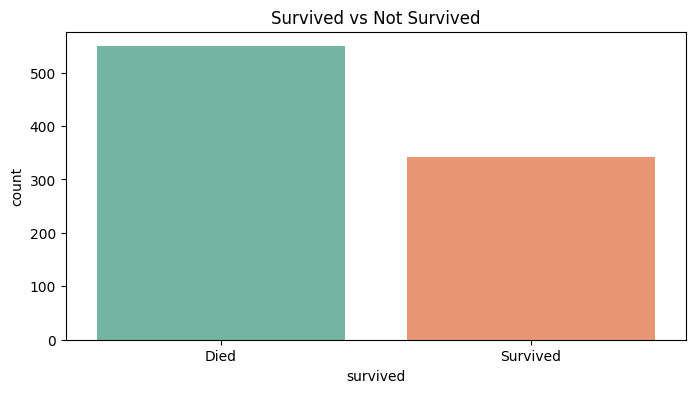

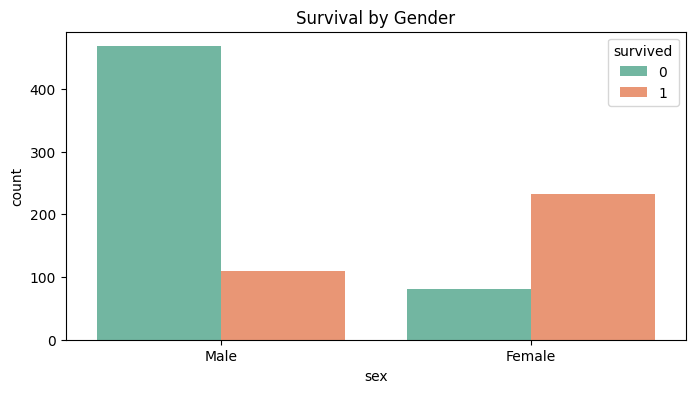

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(x='survived', data=df, palette='Set2')
plt.title('Survived vs Not Survived')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.savefig('survival_count.png', dpi=150)
plt.show()
plt.figure(figsize=(8, 4))
sns.countplot(x='sex', hue='survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.xticks([0, 1], ['Male', 'Female'])
plt.savefig('survival_gender.png', dpi=150)
plt.show()

In [6]:
X = df.drop('survived', axis=1)  
y = df['survived']               
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print("Model training complete! ✅")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [7]:
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].copy()
df['age'] = df['age'].fillna(df['age'].median())
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
X = df.drop('survived', axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print("Model training complete! ✅")

Training samples: 712
Testing samples:  179
Model training complete! ✅


Model Accuracy: 81.01%


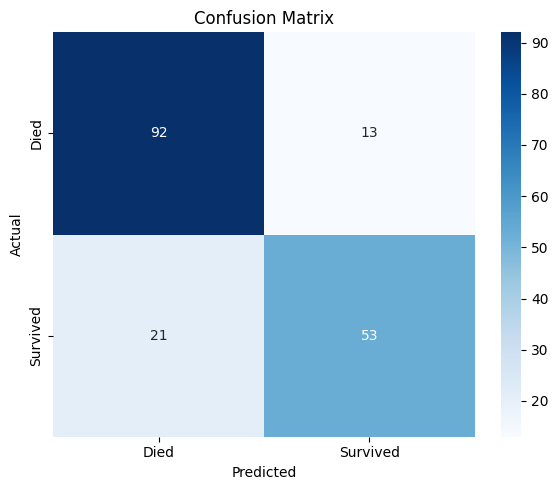

In [8]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [9]:
new_passenger = pd.DataFrame({
    'pclass': [3],     
    'sex':    [0],      
    'age':    [22],    
    'sibsp':  [1],     
    'parch':  [0],      
    'fare':   [7.25]    
})
result = model.predict(new_passenger)[0]
if result == 1:
    print("✅ This passenger would Survive!")
else:
    print("❌ This passenger would NOT survive!")

❌ This passenger would NOT survive!


In [10]:
new_passenger = pd.DataFrame({
    'pclass': [3],
    'sex':    [1],     
    'age':    [22],
    'sibsp':  [1],
    'parch':  [0],
    'fare':   [7.25]
})
result = model.predict(new_passenger)[0]
if result == 1:
    print("✅ This passenger would Survive!")
else:
    print("❌ This passenger would NOT survive!")

✅ This passenger would Survive!
